# 1. Libraries

In [26]:
import pandas as pd
import numpy as np
import re
import os
import ast
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.metrics.pairwise import cosine_similarity


# 2. Helpers

In [2]:
def extract_domain(url):
    pattern = r'\.(.*)'
    domain = re.search(pattern, url)
    if domain:
        return domain.group(0)
    else:
        return None
    
def cosine_similarity_adapter(x, y):
    """ 
    Calcs the cosine similarity between two vectors
    """
    return cosine_similarity(x.reshape(1, -1), y.reshape(1, -1))[0][0]

# 3. Data wrangling

In [3]:
file_path = r"C:\Users\asarr\Documents\Projects\pol-cul-maps-latam\president_csvs\5k"

docs = None

for i, file_name in enumerate(os.listdir(file_path)):
    file_full_path = os.path.join(file_path, file_name)
    df = pd.read_csv(file_full_path)
    
    if docs is None:
        docs = df
    else:
        docs = pd.concat([docs, df], ignore_index=True)

df.head()

,Unnamed: 0,textid,words_number,genre,country,website,url,title,text,id_string,text2,tokenized_text,normalized_text
0,443781,717438,652.0,b,HN,aficionfolklorica.blogspot.com,http://aficionfolklorica.blogspot.com/2009/07/...,Cultura Popular: ¿Y si Zelaya vuelve?,Los Forjadores El historiador hondureño Mario...,717438,los forjadores el historiador hondureño mario...,"['los', 'forjadores', 'el', 'historiador', 'ho...","['forjador', 'historiador', 'hondureño', 'mari..."
1,443788,717450,598.0,b,HN,aficionfolklorica.blogspot.com,http://aficionfolklorica.blogspot.com/2009/09/...,Cultura Popular: Decreto estupido,Los Forjadores El historiador hondureño Mario...,717450,los forjadores el historiador hondureño mario...,"['los', 'forjadores', 'el', 'historiador', 'ho...","['forjador', 'historiador', 'hondureño', 'mari..."
2,443829,717542,672.0,b,HN,aficionfolklorica.blogspot.com,http://aficionfolklorica.blogspot.com/2011_02_...,Cultura Popular: febrero 2011,Los Forjadores El historiador hondureño Mario...,717542,los forjadores el historiador hondureño mario...,"['los', 'forjadores', 'el', 'historiador', 'ho...","['forjador', 'historiador', 'hondureño', 'mari..."
3,443880,717628,551.0,b,HN,arquetipounah.blogspot.com,http://arquetipounah.blogspot.com/2010/03/pint...,ARQUETIPO: Pinta Tu Facu,17.3.10 Pinta Tu Facu PINTA TU FACU MAS DE ...,717628,17310 pinta tu facu pinta tu facu mas de lo...,"['17310', 'pinta', 'tu', 'facu', 'pinta', 'tu'...","['pinta', 'facu', 'pinta', 'facu', 'esperar', ..."
4,443955,717740,508.0,b,HN,audienciasinesperadas.blogspot.com,http://audienciasinesperadas.blogspot.com/2009...,el miedo a que el chancho desfile - audiencias...,jueves 27 de agosto de 2009 EL MIEDO A QUE EL...,717740,jueves 27 de agosto de 2009 el miedo a que el...,"['jueves', '27', 'de', 'agosto', 'de', '2009',...","['jueves', 'agosto', 'miedo', 'chancho', 'desf..."


In [4]:
docs['domain'] = docs['website'].apply(extract_domain)

In [17]:
orgs_df = pd.DataFrame(columns=docs.columns)
govs_df = pd.DataFrame(columns=docs.columns)
blogs_df = pd.DataFrame(columns=docs.columns)
news_df = pd.DataFrame(columns=docs.columns)

# Create lists to store rows temporarily
orgs_list, govs_list, blogs_list, news_list = [], [], [], []

# Iterate through rows
for index, row in docs.iterrows():
    if pd.isna(row['domain']):
        continue
    if 'org' in row['domain']:
        orgs_list.append(row)
    elif 'gov' in row['domain']:
        govs_list.append(row)
    else:
        if row['genre'] == 'b':
            blogs_list.append(row)
        else:
            news_list.append(row)

# Convert lists to DataFrames
orgs_df = pd.concat([orgs_df, pd.DataFrame(orgs_list)], ignore_index=True)
govs_df = pd.concat([govs_df, pd.DataFrame(govs_list)], ignore_index=True)
blogs_df = pd.concat([blogs_df, pd.DataFrame(blogs_list)], ignore_index=True)
news_df = pd.concat([news_df, pd.DataFrame(news_list)], ignore_index=True)

C:\Users\asarr\AppData\Local\Temp\ipykernel_33200\3300935017.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  orgs_df = pd.concat([orgs_df, pd.DataFrame(orgs_list)], ignore_index=True)
C:\Users\asarr\AppData\Local\Temp\ipykernel_33200\3300935017.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  govs_df = pd.concat([govs_df, pd.DataFrame(govs_list)], ignore_index=True)
C:\Users\asarr\AppData\Local\Temp\ipykernel_33200\3300935017.py:26: FutureWarning: The behavior of DataFrame concatenation

In [6]:
names = ['orgs', 'govs', 'blogs', 'news']

# 4. Average cosine similarity in sources

In [20]:
tagged_data = []

for i, pres_df in enumerate([orgs_df, govs_df, blogs_df, news_df]):
    name = names[i]
    # pres_df['normalized_text'] = pres_df['normalized_text'].apply(lambda x: ast.literal_eval(x)) #TODO: quitar si no es necesario
    pres_df = pres_df.sample(500)
    #create list of lists of tagged word
    tagged_data += [TaggedDocument(words=doc, tags=[name + '_' + str(j)]) for j, doc in enumerate(pres_df['normalized_text'])]

#train model
model = Doc2Vec(vector_size=100, window=6, min_count=2, epochs = 40)
model.build_vocab(tagged_data)
model.train(tagged_data, total_examples=model.corpus_count, epochs=model.epochs)

In [21]:
cs_dict = {'Source': []}

for i, vector in enumerate(model.dv.vectors):
    source = model.dv.index_to_key[i].split('_')[0]
    cs_dict['Source'].append(source)
    row = [cosine_similarity_adapter(vector, vector2) for vector2 in model.dv.vectors]
    cs_dict[model.dv.index_to_key[i]] = row

In [23]:
df = pd.DataFrame(cs_dict)
df.head()

,Source,orgs_0,orgs_1,orgs_2,orgs_3,orgs_4,orgs_5,orgs_6,orgs_7,orgs_8,...,news_490,news_491,news_492,news_493,news_494,news_495,news_496,news_497,news_498,news_499
0,orgs,1.000000,0.316701,0.148508,-0.111132,0.107407,0.123563,0.024802,0.236662,-0.002575,...,0.325179,0.177822,0.085940,0.264720,-0.210634,0.178470,0.235198,0.297282,0.125358,-0.007124
1,orgs,0.316701,1.000000,0.066878,0.126513,0.074950,-0.030525,0.266098,-0.224596,0.114916,...,0.195728,-0.088277,-0.014140,0.575668,0.253516,-0.134570,0.162801,0.179482,0.213820,0.143429
2,orgs,0.148508,0.066878,1.000000,-0.213815,0.104353,-0.094505,-0.202187,-0.065187,-0.002986,...,0.226613,-0.216417,0.017602,-0.109634,0.061878,-0.150665,0.302013,0.304903,0.137413,0.043964
3,orgs,-0.111132,0.126513,-0.213815,1.000000,0.408008,0.071473,0.199677,0.214322,0.202416,...,0.164865,0.099982,0.113932,0.122484,0.063982,0.178254,-0.322483,0.089672,-0.137562,0.011095
4,orgs,0.107407,0.074950,0.104353,0.408008,1.000000,0.102265,0.022359,0.349316,0.299968,...,0.318742,0.460909,0.144953,0.133776,-0.020918,-0.034333,0.150699,0.284614,0.026975,0.238230


In [24]:
for column in df.columns:
    if column != 'Source':
        df[column] = pd.to_numeric(df[column], errors='coerce')

In [28]:
sources = df['Source'].unique()

avg_similarity = pd.DataFrame(np.zeros((len(sources), len(sources))), index=sources, columns=sources)

for sour1 in sources:
    for sour2 in sources:

        docs_sour1 = df[df['Source'] == sour1].drop(columns=['Source']).values
        docs_sour2 = df[df['Source'] == sour2].drop(columns=['Source']).values
        
        # Collect similarities between all pairs of documents from pres1 and pres2
        similarities = []
        for doc1 in docs_sour1:
            for doc2 in docs_sour2:
                if not np.array_equal(doc1, doc2):
                    similarities.append(np.dot(doc1, doc2) / (np.linalg.norm(doc1) * np.linalg.norm(doc2)))
        
        # Calculate mean and variance if there are similarities
        if similarities:
            avg_similarity.loc[sour1, sour2] = np.mean(similarities)

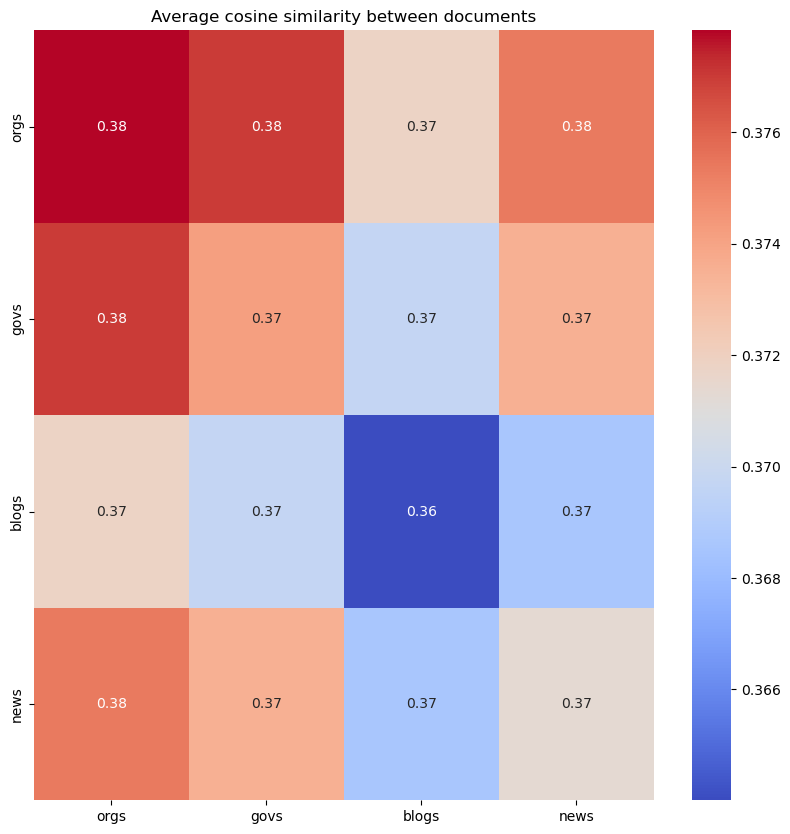

In [29]:
#plot a heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
sns.heatmap(avg_similarity, annot=True, cmap='coolwarm')
plt.title('Average cosine similarity between documents')
plt.show()